# MIT-BIH AFDB — Dummy Classifier Baseline

**Dataset:** MIT-BIH Atrial Fibrillation Database  
**Task:** Binary classification — AFib vs Non-AFib  
**Model:** Dummy Classifiers (no learning — used as a performance floor)  
**Setup:** Same split as the real model: 3 hold-out test + 5-fold CV on 20 records

### Dummy Strategies:
1. **Most Frequent** — always predicts the majority class
2. **Stratified** — predicts randomly but preserves class distribution
3. **Uniform** — predicts each class with equal probability

These give a baseline that any real model should comfortably beat.


## 1. Imports

In [1]:
import os
import numpy as np
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import KFold
from collections import Counter
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import wfdb

print("Imports done.")

Imports done.


## 2. Configuration

In [2]:
class Config:
    data_dir = r"C:/Users/Admin/OneDrive/Skrivebord/Afib-Master/data/MIT-BIH AFDB/files"
    fs = 250
    num_channels = 2
    window_seconds = 4
    window_size = fs * window_seconds
    stride_seconds = 2
    stride_size = fs * stride_seconds
    skip_records = ["00735", "03665"]
    num_classes = 2
    n_folds = 5
    n_test_records = 3
    random_seed = 42

config = Config()
assert os.path.exists(config.data_dir), f"Data path not found: {config.data_dir}"
print(f"Data path OK: {config.data_dir}")
print(f"Window: {config.window_size} samples ({config.window_seconds}s)")
print(f"Stride: {config.stride_size} samples ({config.stride_seconds}s)")

Data path OK: C:/Users/Admin/OneDrive/Skrivebord/Afib-Master/data/MIT-BIH AFDB/files
Window: 1000 samples (4s)
Stride: 500 samples (2s)


## 3. Data Loading & Windowing

In [3]:
def get_record_list(data_dir):
    records = sorted(set(os.path.splitext(f)[0] for f in os.listdir(data_dir) if f.endswith(".dat")))
    print(f"Found {len(records)} records with signal files")
    return records

def load_rhythm_annotations(data_dir, record_name):
    try:
        ann = wfdb.rdann(os.path.join(data_dir, record_name), "atr")
    except Exception as e:
        print(f"  Warning: Could not read annotations for {record_name}: {e}")
        return []
    try:
        record = wfdb.rdheader(os.path.join(data_dir, record_name))
        total_samples = record.sig_len
    except Exception:
        total_samples = 10 * 3600 * config.fs
    segments = []
    for i in range(len(ann.sample)):
        start = ann.sample[i]
        end = ann.sample[i + 1] if i + 1 < len(ann.sample) else total_samples
        label = ann.aux_note[i] if ann.aux_note[i] else None
        if label:
            label = label.strip().strip("(").strip()
            if label in ("AFIB", "AF"): label = "AF"
            elif label == "AFL": label = "AFL"
            elif label == "J": label = "J"
            else: label = "N"
        if label and end > start:
            segments.append((start, end, label))
    return segments

def create_windows_for_record(data_dir, record_name, config):
    try:
        record = wfdb.rdrecord(os.path.join(data_dir, record_name))
        signal = record.p_signal
        if signal.shape[1] < config.num_channels:
            signal = np.column_stack([signal[:, 0]] * config.num_channels)
    except Exception as e:
        print(f"  Warning: Could not read signal for {record_name}: {e}")
        return None, None, None
    segments = load_rhythm_annotations(data_dir, record_name)
    if not segments:
        return None, None, None
    total_samples = len(signal)
    sample_labels = np.zeros(total_samples, dtype=np.int64)
    afib_events = 0
    for start, end, rhythm in segments:
        if rhythm == "AF":
            sample_labels[max(start, 0):min(end, total_samples)] = 1
            afib_events += 1
    windows, labels = [], []
    win_start = 0
    while win_start + config.window_size <= total_samples:
        win_end = win_start + config.window_size
        win_signal = signal[win_start:win_end, :config.num_channels].copy()
        if np.any(np.isnan(win_signal)):
            win_start += config.stride_size
            continue
        valid = True
        for ch in range(config.num_channels):
            std = np.std(win_signal[:, ch])
            if std < 1e-6:
                valid = False
                break
        if not valid:
            win_start += config.stride_size
            continue
        windows.append(1)  # placeholder — dummy doesn't use features
        afib_ratio = np.mean(sample_labels[win_start:win_end])
        labels.append(1 if afib_ratio > 0.5 else 0)
        win_start += config.stride_size
    if not windows:
        return None, None, None
    labels = np.array(labels, dtype=np.int64)
    stats = {"afib_events": afib_events, "total_windows": len(labels),
             "afib_windows": int(np.sum(labels == 1)), "non_afib_windows": int(np.sum(labels == 0))}
    return len(labels), labels, stats

print("Functions defined.")

Functions defined.


## 4. Load All Records

In [4]:
records = get_record_list(config.data_dir)
records = [r for r in records if r not in config.skip_records]
all_record_data = {}
total_stats = {"afib_events": 0, "total_windows": 0, "afib_windows": 0, "non_afib_windows": 0}

print(f"\n{'Record':<10} {'AFib Events':<15} {'Total Win':<12} {'AFib Win':<12} {'Non-AFib Win':<15}")
print("-" * 65)
for record_name in records:
    n_windows, labels, stats = create_windows_for_record(config.data_dir, record_name, config)
    if labels is not None:
        all_record_data[record_name] = labels
        for key in total_stats:
            total_stats[key] += stats[key]
        print(f"{record_name:<10} {stats['afib_events']:<15} {stats['total_windows']:<12} {stats['afib_windows']:<12} {stats['non_afib_windows']:<15}")
print("-" * 65)
print(f"{'TOTAL':<10} {total_stats['afib_events']:<15} {total_stats['total_windows']:<12} {total_stats['afib_windows']:<12} {total_stats['non_afib_windows']:<15}")
print(f"\nRecords loaded: {len(all_record_data)}")

Found 23 records with signal files

Record     AFib Events     Total Win    AFib Win     Non-AFib Win   
-----------------------------------------------------------------
04015      7               18410        119          18291          
04043      82              18407        3966         14441          
04048      7               18410        180          18230          
04126      7               18410        688          17722          
04746      5               18410        9776         8634           
04908      8               18410        1541         16869          
04936      36              18410        13281        5129           
05091      8               18410        41           18369          
05121      20              18410        11604        6806           
05261      11              18410        242          18168          
06426      26              18410        17559        851            
06453      6               16649        187          16462          
0

## 5. Helper Functions

In [5]:
def merge_labels(record_list):
    return np.concatenate([all_record_data[r] for r in record_list])

def compute_all_metrics(targets, preds, probs):
    cm = confusion_matrix(targets, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(targets, preds)
    prec = precision_score(targets, preds, pos_label=1, zero_division=0)
    rec = recall_score(targets, preds, pos_label=1, zero_division=0)
    f1 = f1_score(targets, preds, pos_label=1, zero_division=0)
    mcc = matthews_corrcoef(targets, preds)
    try:
        auroc = roc_auc_score(targets, probs)
    except ValueError:
        auroc = 0.5
    try:
        auprc = average_precision_score(targets, probs)
    except ValueError:
        auprc = np.mean(targets)
    brier = brier_score_loss(targets, probs)
    n_bins = 10
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece, mce = 0.0, 0.0
    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (probs >= bin_boundaries[i]) & (probs < bin_boundaries[i + 1])
        else:
            mask = (probs >= bin_boundaries[i]) & (probs <= bin_boundaries[i + 1])
        bin_count = mask.sum()
        if bin_count > 0:
            bin_acc = targets[mask].mean()
            bin_conf = probs[mask].mean()
            cal_error = abs(bin_acc - bin_conf)
            ece += (bin_count / len(targets)) * cal_error
            mce = max(mce, cal_error)
    metrics = {"tn": tn, "fp": fp, "fn": fn, "tp": tp, "accuracy": acc, "precision": prec,
               "recall": rec, "f1": f1, "mcc": mcc, "auroc": auroc, "auprc": auprc,
               "brier": brier, "ece": ece, "mce": mce, "cm": cm}
    return metrics

print("Helper functions defined.")

Helper functions defined.


## 6. Split: Hold-Out Test + 5-Fold CV

Same split as the real model notebook for fair comparison.

In [6]:
np.random.seed(config.random_seed)
record_names = sorted(all_record_data.keys())
shuffled = np.random.permutation(record_names).tolist()

test_records = shuffled[:config.n_test_records]
cv_records = shuffled[config.n_test_records:]

print(f"Hold-out test records ({len(test_records)}): {test_records}")
print(f"CV records ({len(cv_records)}): {cv_records}")

test_labels = merge_labels(test_records)
print(f"\nTest set: {len(test_labels):,} windows (AFib: {np.sum(test_labels==1):,}, Non-AFib: {np.sum(test_labels==0):,})")

kf = KFold(n_splits=config.n_folds, shuffle=True, random_state=config.random_seed)
folds = []
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(cv_records)):
    train_recs = [cv_records[i] for i in train_idx]
    val_recs = [cv_records[i] for i in val_idx]
    folds.append({"train": train_recs, "val": val_recs})

for i, fold in enumerate(folds):
    val_labels = merge_labels(fold["val"])
    print(f"Fold {i+1}: Val {len(val_labels):,} windows (AFib: {np.sum(val_labels==1):,})")

Hold-out test records (3): ['07879', '05261', '04015']
CV records (20): ['05121', '08215', '06995', '04043', '07162', '04908', '04048', '06453', '08405', '04126', '04746', '08219', '07910', '08434', '08455', '05091', '06426', '07859', '08378', '04936']

Test set: 55,230 windows (AFib: 11,462, Non-AFib: 43,768)
Fold 1: Val 73,640 windows (AFib: 44,891)
Fold 2: Val 73,634 windows (AFib: 22,772)
Fold 3: Val 73,631 windows (AFib: 30,793)
Fold 4: Val 73,640 windows (AFib: 35,313)
Fold 5: Val 71,879 windows (AFib: 22,878)


## 7. Run Dummy Classifiers — 5-Fold CV + Test

Three strategies:
- **most_frequent**: Always predicts majority class → shows accuracy of "always guess normal"
- **stratified**: Random guessing proportional to class distribution → expected random baseline
- **uniform**: 50/50 random coin flip → worst-case random baseline

In [7]:
strategies = ["most_frequent", "stratified", "uniform"]
all_results = {}

for strategy in strategies:
    print(f"\n{'='*70}")
    print(f"DUMMY CLASSIFIER: {strategy.upper()}")
    print(f"{'='*70}")

    fold_metrics_list = []
    fold_targets_list = []
    fold_probs_list = []

    for fold_idx, fold in enumerate(folds):
        y_train = merge_labels(fold["train"])
        y_val = merge_labels(fold["val"])

        # Dummy classifier only needs labels, not features
        # We create dummy feature arrays (single column of zeros)
        X_train_dummy = np.zeros((len(y_train), 1))
        X_val_dummy = np.zeros((len(y_val), 1))

        clf = DummyClassifier(strategy=strategy, random_state=config.random_seed + fold_idx)
        clf.fit(X_train_dummy, y_train)

        preds = clf.predict(X_val_dummy)
        probs = clf.predict_proba(X_val_dummy)[:, 1]

        metrics = compute_all_metrics(y_val, preds, probs)
        fold_metrics_list.append(metrics)
        fold_targets_list.append(y_val)
        fold_probs_list.append(probs)

        print(f"  Fold {fold_idx+1}: Acc={metrics['accuracy']:.4f} F1={metrics['f1']:.4f} MCC={metrics['mcc']:.4f} AUROC={metrics['auroc']:.4f}")

    # Test set evaluation
    y_train_all_cv = merge_labels(cv_records)
    X_train_all = np.zeros((len(y_train_all_cv), 1))
    X_test_dummy = np.zeros((len(test_labels), 1))

    clf_test = DummyClassifier(strategy=strategy, random_state=config.random_seed)
    clf_test.fit(X_train_all, y_train_all_cv)
    test_preds = clf_test.predict(X_test_dummy)
    test_probs = clf_test.predict_proba(X_test_dummy)[:, 1]
    test_metrics = compute_all_metrics(test_labels, test_preds, test_probs)

    print(f"\n  Test: Acc={test_metrics['accuracy']:.4f} F1={test_metrics['f1']:.4f} MCC={test_metrics['mcc']:.4f} AUROC={test_metrics['auroc']:.4f}")

    all_results[strategy] = {
        "fold_metrics": fold_metrics_list,
        "fold_targets": fold_targets_list,
        "fold_probs": fold_probs_list,
        "test_metrics": test_metrics,
        "test_targets": test_labels,
        "test_probs": test_probs,
    }

print("\n\nAll dummy classifiers evaluated.")


DUMMY CLASSIFIER: MOST_FREQUENT
  Fold 1: Acc=0.3904 F1=0.0000 MCC=0.0000 AUROC=0.5000
  Fold 2: Acc=0.6907 F1=0.0000 MCC=0.0000 AUROC=0.5000
  Fold 3: Acc=0.5818 F1=0.0000 MCC=0.0000 AUROC=0.5000
  Fold 4: Acc=0.5205 F1=0.0000 MCC=0.0000 AUROC=0.5000
  Fold 5: Acc=0.6817 F1=0.0000 MCC=0.0000 AUROC=0.5000

  Test: Acc=0.7925 F1=0.0000 MCC=0.0000 AUROC=0.5000

DUMMY CLASSIFIER: STRATIFIED
  Fold 1: Acc=0.4713 F1=0.4666 MCC=-0.0060 AUROC=0.4970
  Fold 2: Acc=0.5163 F1=0.3714 MCC=0.0024 AUROC=0.5013
  Fold 3: Acc=0.5108 F1=0.4215 MCC=-0.0022 AUROC=0.4989
  Fold 4: Acc=0.5046 F1=0.4472 MCC=0.0023 AUROC=0.5012
  Fold 5: Acc=0.5169 F1=0.3753 MCC=0.0012 AUROC=0.5006

  Test: Acc=0.5377 F1=0.2719 MCC=-0.0119 AUROC=0.4928

DUMMY CLASSIFIER: UNIFORM
  Fold 1: Acc=0.5037 F1=0.5532 MCC=0.0071 AUROC=0.5000
  Fold 2: Acc=0.4999 F1=0.3817 MCC=-0.0005 AUROC=0.5000
  Fold 3: Acc=0.4997 F1=0.4551 MCC=-0.0006 AUROC=0.5000
  Fold 4: Acc=0.5015 F1=0.4912 MCC=0.0031 AUROC=0.5000
  Fold 5: Acc=0.5005 F1=0.3

## 8. Summary Table — All Strategies

In [8]:
metric_names = ["accuracy", "precision", "recall", "f1", "mcc", "auroc", "auprc", "brier", "ece", "mce"]

print("=" * 100)
print("DUMMY CLASSIFIER RESULTS SUMMARY")
print("=" * 100)
print()

header = f"{'Metric':<15}"
for s in strategies:
    header += f"{'CV ' + s:<22}"
header += f"{'Test most_freq':<18}{'Test stratified':<18}{'Test uniform':<18}"
print(header)
print("-" * 100)

for m in metric_names:
    row = f"{m.upper():<15}"
    for s in strategies:
        vals = [f[m] for f in all_results[s]["fold_metrics"]]
        mean_v = np.mean(vals)
        std_v = np.std(vals)
        row += f"{mean_v:.4f}+/-{std_v:.4f}    "
    for s in strategies:
        row += f"{all_results[s]['test_metrics'][m]:<18.4f}"
    print(row)

print()
print("Confusion matrix (Test set):")
print("-" * 60)
for s in strategies:
    tm = all_results[s]["test_metrics"]
    print(f"  {s:<16} TN={tm['tn']:<8} FP={tm['fp']:<8} FN={tm['fn']:<8} TP={tm['tp']}")

print("=" * 100)

DUMMY CLASSIFIER RESULTS SUMMARY

Metric         CV most_frequent      CV stratified         CV uniform            Test most_freq    Test stratified   Test uniform      
----------------------------------------------------------------------------------------------------
ACCURACY       0.5730+/-0.1112    0.5039+/-0.0169    0.5011+/-0.0015    0.7925            0.5377            0.5016            
PRECISION      0.0000+/-0.0000    0.4266+/-0.1098    0.4279+/-0.1125    0.0000            0.2020            0.2082            
RECALL         0.0000+/-0.0000    0.4283+/-0.0297    0.5008+/-0.0018    0.0000            0.4159            0.5000            
F1             0.0000+/-0.0000    0.4164+/-0.0380    0.4541+/-0.0643    0.0000            0.2719            0.2940            
MCC            0.0000+/-0.0000    -0.0005+/-0.0032    0.0019+/-0.0029    0.0000            -0.0119           0.0016            
AUROC          0.5000+/-0.0000    0.4998+/-0.0016    0.5000+/-0.0000    0.5000            0.4

## 9. Confusion Matrices — All Strategies (Test Set)

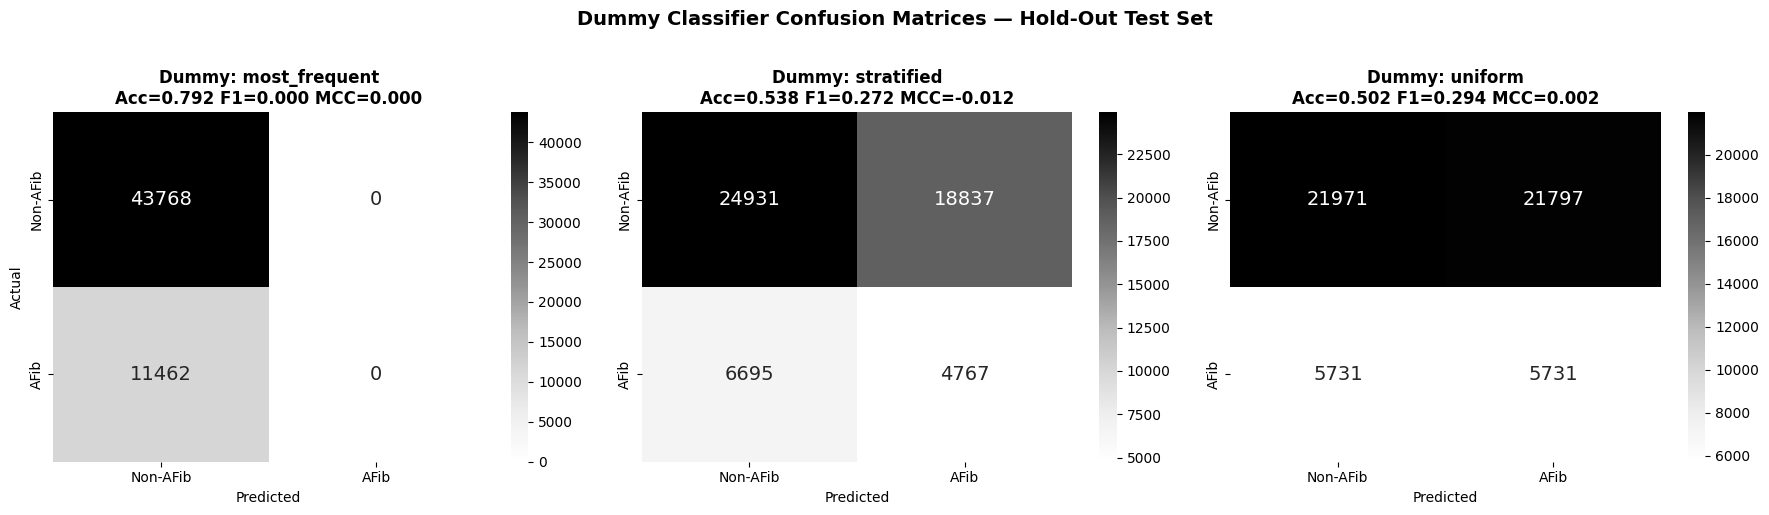

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, strategy in enumerate(strategies):
    ax = axes[i]
    tm = all_results[strategy]["test_metrics"]
    sns.heatmap(tm["cm"], annot=True, fmt="d", cmap="Greys",
                xticklabels=["Non-AFib", "AFib"], yticklabels=["Non-AFib", "AFib"],
                ax=ax, annot_kws={"size": 14})
    ax.set_title(f"Dummy: {strategy}\nAcc={tm['accuracy']:.3f} F1={tm['f1']:.3f} MCC={tm['mcc']:.3f}",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual" if i == 0 else "")

plt.suptitle("Dummy Classifier Confusion Matrices — Hold-Out Test Set", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. ROC Curves — Dummy vs Random

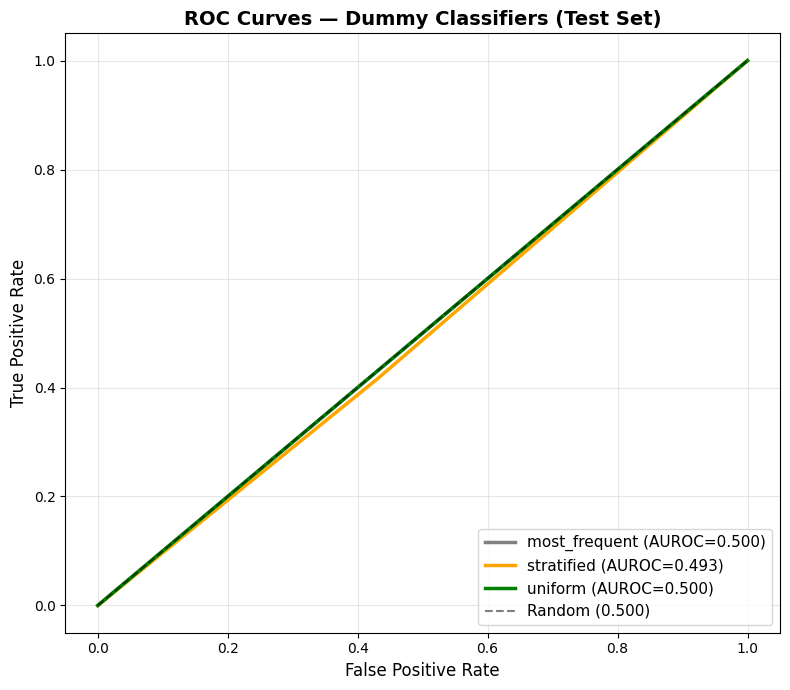

In [10]:
fig, ax = plt.subplots(figsize=(8, 7))
colors = {"most_frequent": "gray", "stratified": "orange", "uniform": "green"}

for strategy in strategies:
    tm = all_results[strategy]
    try:
        fpr, tpr, _ = roc_curve(tm["test_targets"], tm["test_probs"])
        ax.plot(fpr, tpr, linewidth=2.5, color=colors[strategy],
                label=f'{strategy} (AUROC={tm["test_metrics"]["auroc"]:.3f})')
    except Exception:
        ax.plot([0, 1], [0, 1], linewidth=2.5, color=colors[strategy],
                label=f'{strategy} (AUROC=0.500)')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Dummy Classifiers (Test Set)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Precision-Recall Curves — Dummy vs Baseline

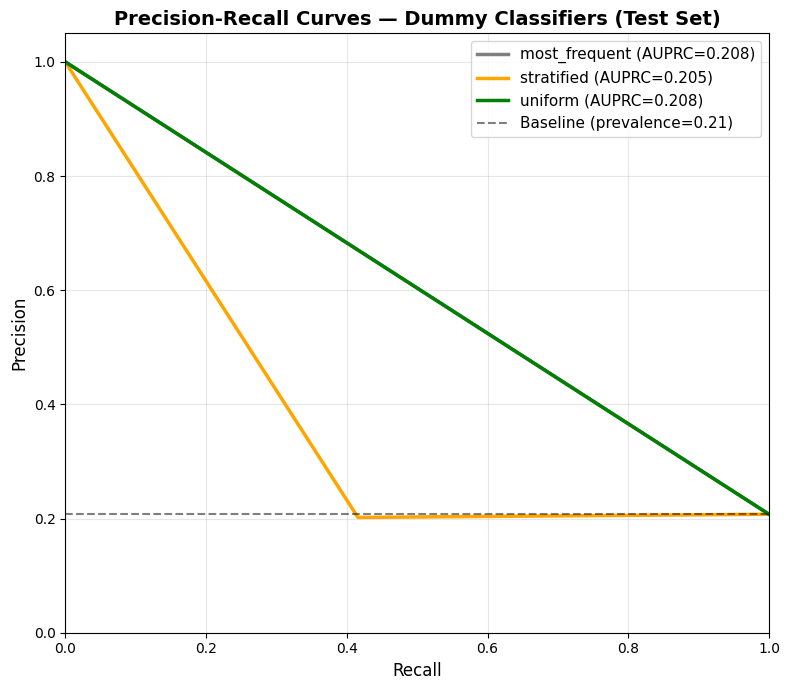

In [11]:
fig, ax = plt.subplots(figsize=(8, 7))

for strategy in strategies:
    tm = all_results[strategy]
    try:
        prec_c, rec_c, _ = precision_recall_curve(tm["test_targets"], tm["test_probs"])
        ax.plot(rec_c, prec_c, linewidth=2.5, color=colors[strategy],
                label=f'{strategy} (AUPRC={tm["test_metrics"]["auprc"]:.3f})')
    except Exception:
        pass

baseline = np.mean(test_labels)
ax.axhline(y=baseline, color='k', linestyle='--', alpha=0.5, label=f'Baseline (prevalence={baseline:.2f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — Dummy Classifiers (Test Set)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

## 12. Metrics Bar Chart — Dummy Strategies Compared

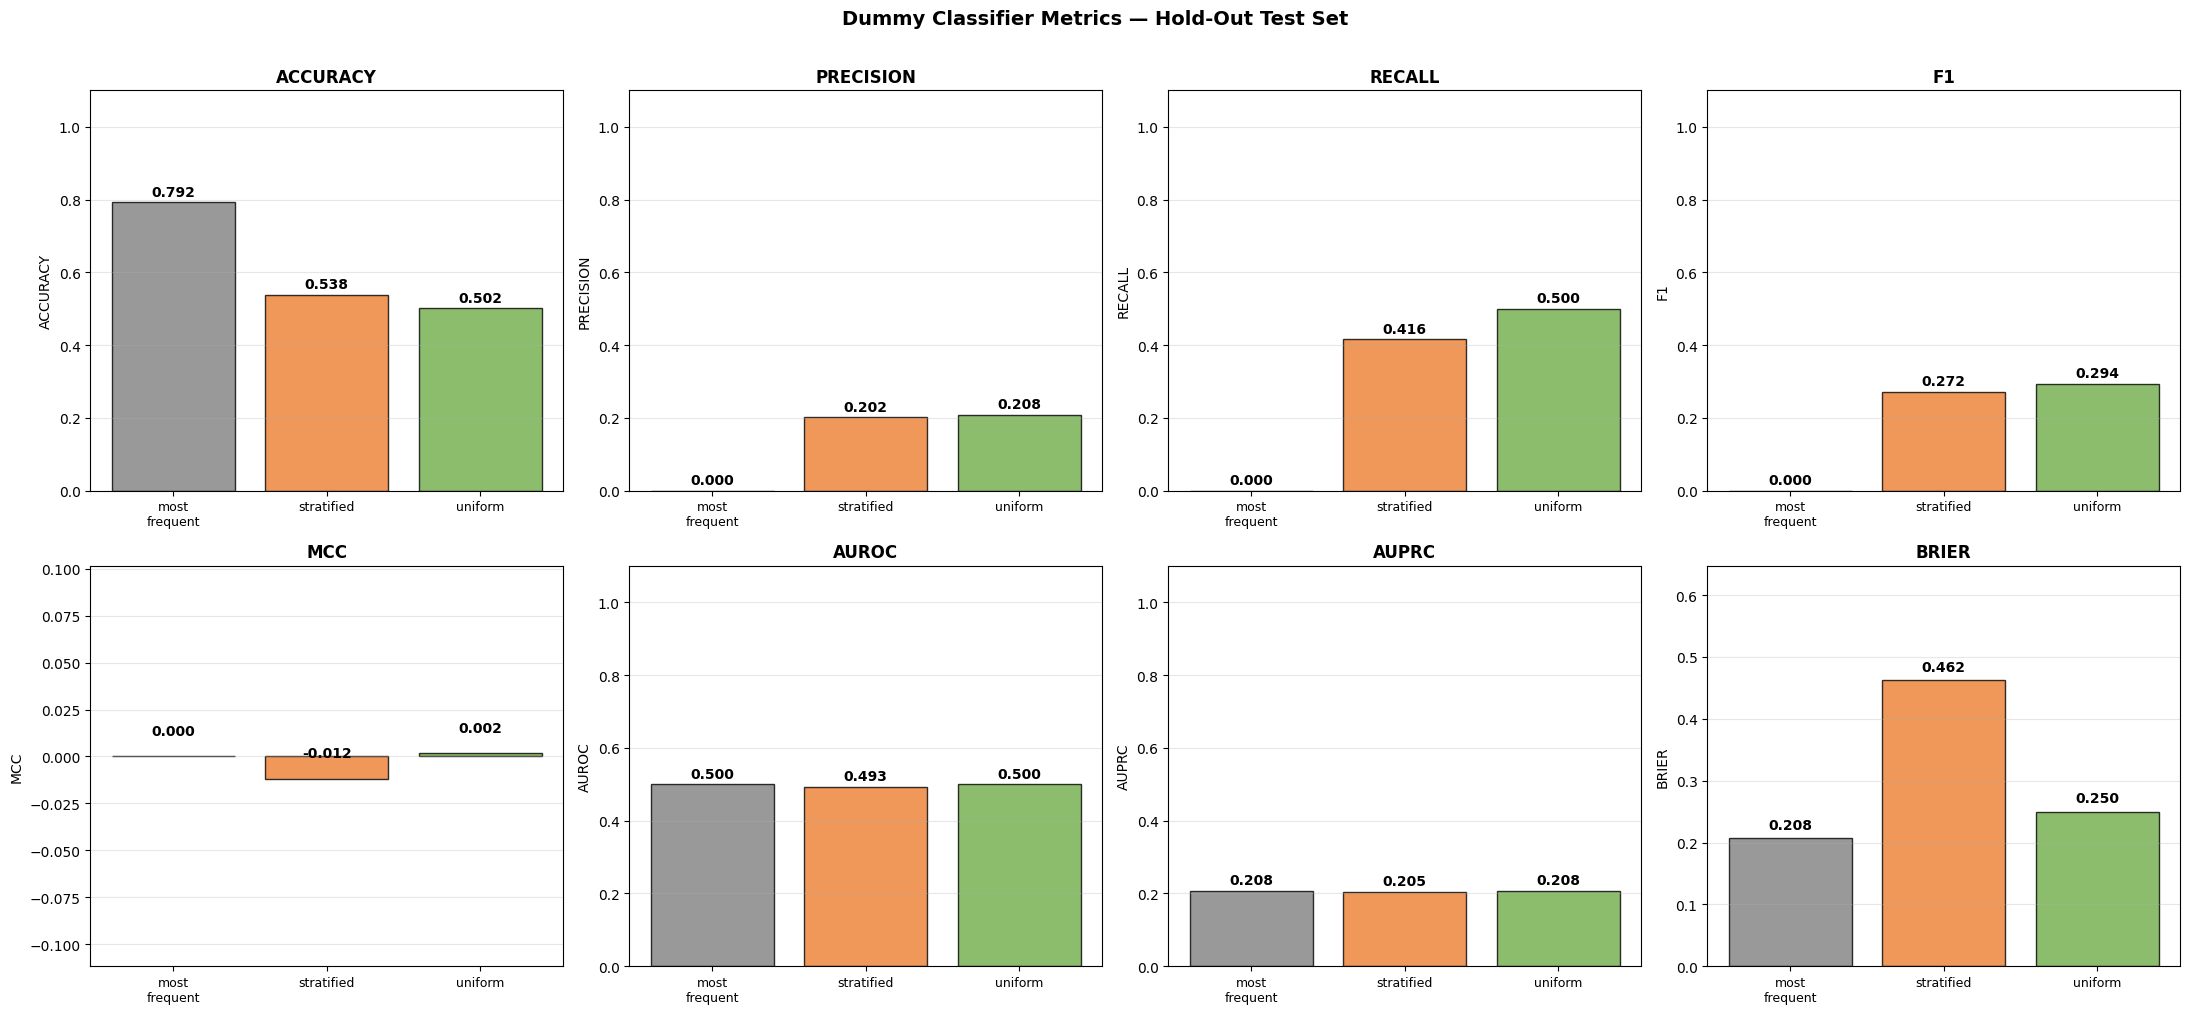

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
plot_metrics = ["accuracy", "precision", "recall", "f1", "mcc", "auroc", "auprc", "brier"]
bar_colors = {"most_frequent": "#808080", "stratified": "#ED7D31", "uniform": "#70AD47"}

for idx, metric in enumerate(plot_metrics):
    row, col = idx // 4, idx % 4
    ax = axes[row][col]
    x = np.arange(len(strategies))
    vals = [all_results[s]["test_metrics"][metric] for s in strategies]
    bars = ax.bar(x, vals, color=[bar_colors[s] for s in strategies], edgecolor='black', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([s.replace("_", "\n") for s in strategies], fontsize=9)
    ax.set_ylabel(metric.upper())
    ax.set_title(metric.upper(), fontsize=12, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    if metric == "brier":
        ax.set_ylim([0, max(vals) * 1.4])
    elif metric == "mcc":
        ax.set_ylim([min(min(vals) - 0.1, -0.1), max(max(vals) + 0.1, 0.1)])
    else:
        ax.set_ylim([0, 1.1])

plt.suptitle("Dummy Classifier Metrics — Hold-Out Test Set", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 13. Calibration Plots — Dummy Classifiers

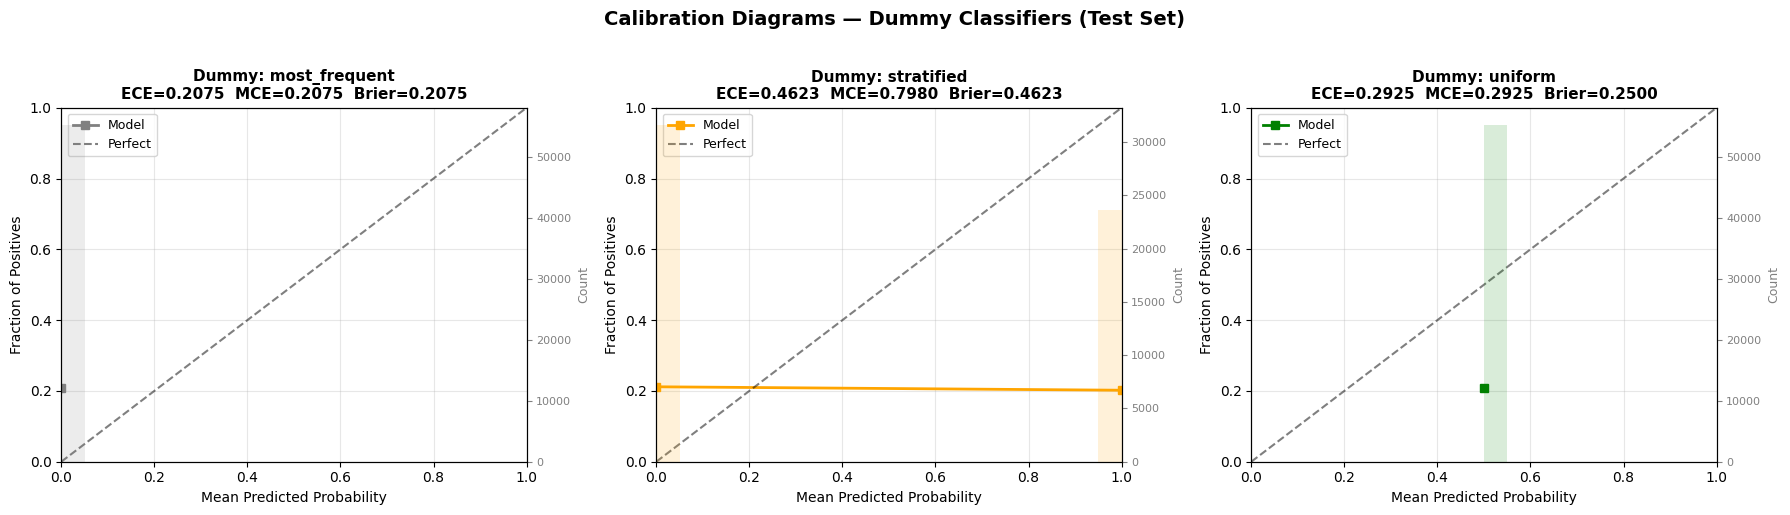

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, strategy in enumerate(strategies):
    ax = axes[i]
    tm = all_results[strategy]
    try:
        fraction_pos, mean_predicted = calibration_curve(
            tm["test_targets"], tm["test_probs"], n_bins=10, strategy='uniform')
        ax.plot(mean_predicted, fraction_pos, 's-', color=colors[strategy], linewidth=2, markersize=6, label='Model')
    except Exception:
        pass
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    ax2 = ax.twinx()
    ax2.hist(tm["test_probs"], bins=20, range=(0, 1), alpha=0.15, color=colors[strategy])
    ax2.set_ylabel('Count', fontsize=9, alpha=0.5)
    ax2.tick_params(axis='y', labelsize=8, colors='gray')
    met = tm["test_metrics"]
    ax.set_title(f"Dummy: {strategy}\nECE={met['ece']:.4f}  MCE={met['mce']:.4f}  Brier={met['brier']:.4f}",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)

plt.suptitle("Calibration Diagrams — Dummy Classifiers (Test Set)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 14. Final Summary

In [14]:
print("=" * 70)
print("DUMMY CLASSIFIER BASELINE SUMMARY")
print("=" * 70)
print()
print("These results represent the FLOOR that any real model must beat.")
print("If a model cannot outperform the dummy, it has not learned anything useful.")
print()

metric_names_summary = ["accuracy", "precision", "recall", "f1", "mcc", "auroc", "auprc", "brier", "ece", "mce"]

for strategy in strategies:
    tm = all_results[strategy]["test_metrics"]
    cv_metrics = all_results[strategy]["fold_metrics"]
    print(f"\n--- {strategy.upper()} ---")
    print(f"{'Metric':<15} {'CV Mean +/- Std':<25} {'Test':<10}")
    print("-" * 50)
    for m in metric_names_summary:
        cv_vals = [f[m] for f in cv_metrics]
        print(f"{m.upper():<15} {np.mean(cv_vals):.4f} +/- {np.std(cv_vals):.4f}     {tm[m]:.4f}")

print()
print(f"\nDataset: {len(all_record_data)} records")
print(f"Hold-out test: {test_records}")
print(f"AFib prevalence (test): {np.mean(test_labels):.2%}")
print(f"AFib prevalence (CV):   {np.mean(merge_labels(cv_records)):.2%}")

DUMMY CLASSIFIER BASELINE SUMMARY

These results represent the FLOOR that any real model must beat.
If a model cannot outperform the dummy, it has not learned anything useful.


--- MOST_FREQUENT ---
Metric          CV Mean +/- Std           Test      
--------------------------------------------------
ACCURACY        0.5730 +/- 0.1112     0.7925
PRECISION       0.0000 +/- 0.0000     0.0000
RECALL          0.0000 +/- 0.0000     0.0000
F1              0.0000 +/- 0.0000     0.0000
MCC             0.0000 +/- 0.0000     0.0000
AUROC           0.5000 +/- 0.0000     0.5000
AUPRC           0.4270 +/- 0.1112     0.2075
BRIER           0.4270 +/- 0.1112     0.2075
ECE             0.4270 +/- 0.1112     0.2075
MCE             0.4270 +/- 0.1112     0.2075

--- STRATIFIED ---
Metric          CV Mean +/- Std           Test      
--------------------------------------------------
ACCURACY        0.5039 +/- 0.0169     0.5377
PRECISION       0.4266 +/- 0.1098     0.2020
RECALL          0.4283 +/- 0.029